# **دانا حسن بافقيه**
#  شعبه 2


#**Import libraries:**

In [ ]:
# For the dataset
import pandas as pd
import numpy as np

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# For preprocessing
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# For Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report, auc, roc_curve, roc_auc_score

# For Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Step 1: Data Preprocessing

##Load the dataset

In [ ]:
# Read the data
adult = pd.read_csv('/content/adult[1].data',
                    header = None,              # The data without header
                    delimiter=' *, *', engine='python')

In [ ]:
# Add header to the dataset
adult.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
                    'marital_status', 'occupation', 'relationship',
                    'race', 'sex', 'capital_gain', 'capital_loss',
                    'hours_per_week', 'native_country', 'income']

In [ ]:
# Print the first 5 rows
adult.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


##Handling Missing Value

In [ ]:
# Show information about the data (columns, type, null count)
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Check for missing vlues value
adult.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


Even though it shows no missing value (null), but the data source indicates that some value are missing!  

This means they may not be null, but the column contains invalid or missing values.

In [ ]:
# Check the unique values for columns that may contain missing or invalid values
for col in ['workclass', 'occupation', 'native_country']:
    print(f"Column: {col}")
    print(adult[col].unique())
    print("\n")

Column: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


Column: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' '?'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']


Column: native_country
['United-States' 'Cuba' 'Jamaica' 'India' '?' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']






We can observe that some entries contain `?` value




In [ ]:
# Replace the '?' with the mode because these are categorical features
for col in ['workclass', 'occupation', 'native_country']:
  adult[col] = adult[col].replace('?', adult[col].mode()[0])

In [ ]:
# Check again
for col in ['workclass', 'occupation', 'native_country']:
    print(f"Column: {col}")
    print(adult[col].unique())
    print("\n")

Column: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']


Column: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']


Column: native_country
['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Canada' 'Germany' 'Iran' 'Philippines' 'Italy'
 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador' 'Laos' 'Taiwan'
 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador' 'France'
 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary' 'Holand-Netherlands']




We can see that there are **no** more `?` values remaining

##Data Encoding

In [ ]:
# Encode the 'sex' column with LabelEncoder because it's' binary
adult['sex'] = LabelEncoder().fit_transform(adult['sex'])

# Encode remaining categorical features with One-Hot because there is no ordering in the data
adultE = pd.get_dummies( adult, columns=['workclass', 'education', 'marital_status', 'occupation',
             'relationship', 'race', 'native_country'], dtype=int)

print(adultE.head())

   age  fnlwgt  education_num  sex  capital_gain  capital_loss  \
0   39   77516             13    1          2174             0   
1   50   83311             13    1             0             0   
2   38  215646              9    1             0             0   
3   53  234721              7    1             0             0   
4   28  338409             13    0             0             0   

   hours_per_week income  workclass_Federal-gov  workclass_Local-gov  ...  \
0              40  <=50K                      0                    0  ...   
1              13  <=50K                      0                    0  ...   
2              40  <=50K                      0                    0  ...   
3              40  <=50K                      0                    0  ...   
4              40  <=50K                      0                    0  ...   

   native_country_Portugal  native_country_Puerto-Rico  \
0                        0                           0   
1                       

##Data Normalization

In [ ]:
# Show statistical summary
adultE.describe()

,age,fnlwgt,education_num,sex,capital_gain,capital_loss,hours_per_week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native_country_Portugal,native_country_Puerto-Rico,native_country_Scotland,native_country_South,native_country_Taiwan,native_country_Thailand,native_country_Trinadad&Tobago,native_country_United-States,native_country_Vietnam,native_country_Yugoslavia
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,...,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,0.669205,1077.648844,87.303830,40.437456,0.029483,0.064279,0.000215,...,0.001136,0.003501,0.000369,0.002457,0.001566,0.000553,0.000584,0.913762,0.002058,0.000491
std,13.640433,1.055500e+05,2.572720,0.470506,7385.292085,402.960219,12.347429,0.169159,0.245254,0.014661,...,0.033691,0.059068,0.019194,0.049507,0.039546,0.023506,0.024149,0.280720,0.045316,0.022162
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,37.000000,1.783560e+05,10.000000,1.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,48.000000,2.370510e+05,12.000000,1.000000,0.000000,0.000000,45.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,90.000000,1.484705e+06,16.000000,1.000000,99999.000000,4356.000000,99.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


As we can see some columns have a large difference between the minimum and maximum values.

For example:

* column **capital_gain**: has min = **0**, max = **99999**
* column **capital_loss**: has min **0**, max **4356**

so, we need to normalize the data.

----
Because normalization is applied only to **numerical features**, i split the data into features and target before applying normalization.


In [ ]:
# Split features and target
X = adultE.drop(['income'], axis=1)
y = adultE['income']

In [ ]:
# Applying normalization to scale features between 0 and 1.
scaler = MinMaxScaler()
normX = scaler.fit_transform(X)

In [ ]:
#Split the dataset into training and testing sets (70% train, 30% test).
X_train, X_test, y_train, y_test = train_test_split(
    normX, y, test_size=0.3, random_state=42
    )

#Step 2: Model Building

In [ ]:
# Build a Logistic Regression Classifier
model1 = LogisticRegression()

# Model training
model1.fit(X_train, y_train)

LogisticRegression()

In [ ]:
# Predict the classes for the test set
y_pred_LOG = model1.predict(X_test)
print("Predict classes",y_pred_LOG)

# Predict the probabilities for the test set
y_probs_LOG = model1.predict_proba(X_test)[:, 1]
print("Predict probabilities",y_probs_LOG)

Predict classes ['<=50K' '<=50K' '>50K' ... '<=50K' '<=50K' '>50K']
Predict probabilities [0.02733206 0.48853076 0.69515524 ... 0.01907129 0.4303986  0.84006171]


In [ ]:
# Build a Gaussian NB Classifier
model2 = GaussianNB()

# Model training
model2.fit(X_train, y_train)

GaussianNB()

In [ ]:
# Predict the classes for the test set
y_pred_GNB = model2.predict(X_test)
print("Predict classes",y_pred_GNB)

# Predict the probabilities for the test set
y_probs_GNB = model2.predict_proba(X_test)[:, 1]
print("Predict probabilities",y_probs_GNB)

Predict classes ['>50K' '>50K' '>50K' ... '<=50K' '>50K' '>50K']
Predict probabilities [1.         1.         1.         ... 0.18691957 1.         1.        ]


#**Step 3: Model Evaluation and Visualization**

In [ ]:
print("\nLogistic Regression")

# Model Evaluation Metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred_LOG))
print("\nPrecision:", precision_score(y_test, y_pred_LOG, pos_label='>50K'))
print("\nRecall:", recall_score(y_test, y_pred_LOG, pos_label='>50K'))
print("\nF1 Score:", f1_score(y_test, y_pred_LOG, pos_label='>50K'))
print("\nAUC - ROC Score:", roc_auc_score(y_test, y_probs_LOG))

print("-----------------------------------------------")

# Classification report
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_LOG))


Logistic Regression

Accuracy: 0.8506500153546934

Precision: 0.7272727272727273

Recall: 0.5911840968020743

F1 Score: 0.6522050059594756

AUC - ROC Score: 0.902076185143126
-----------------------------------------------

Logistic Regression Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7455
        >50K       0.73      0.59      0.65      2314

    accuracy                           0.85      9769
   macro avg       0.80      0.76      0.78      9769
weighted avg       0.84      0.85      0.85      9769



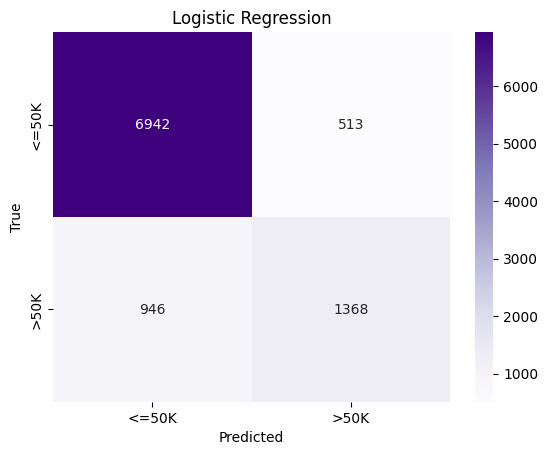

In [ ]:
# Visualize the confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_LOG, labels = ['<=50K', '>50K'])
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression')
plt.show()

In [ ]:
print("Gaussian Naive Bayes\n")

# Model Evaluation Metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred_GNB))
print("\nPrecision:", precision_score(y_test, y_pred_GNB, pos_label='>50K'))
print("\nRecall:", recall_score(y_test, y_pred_GNB, pos_label='>50K'))
print("\nF1 Score:", f1_score(y_test, y_pred_GNB, pos_label='>50K'))
print("\nAUC - ROC Score:", roc_auc_score(y_test, y_probs_GNB))

print("-----------------------------------------------")

# Classification report
print("\nGaussian Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_GNB))

Gaussian Naive Bayes


Accuracy: 0.5011771931620432

Precision: 0.317864768683274

Recall: 0.9649956784788245

F1 Score: 0.47820965842167257

AUC - ROC Score: 0.7131689010467298
-----------------------------------------------

Gaussian Naive Bayes Classification Report:
              precision    recall  f1-score   support

       <=50K       0.97      0.36      0.52      7455
        >50K       0.32      0.96      0.48      2314

    accuracy                           0.50      9769
   macro avg       0.64      0.66      0.50      9769
weighted avg       0.82      0.50      0.51      9769



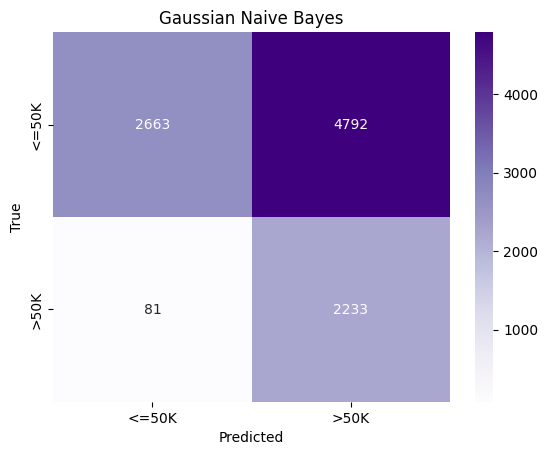

In [ ]:
# Visualize the confusion matrix for Gaussian Naive Bayes
cm = confusion_matrix(y_test, y_pred_GNB, labels = ['<=50K', '>50K'])
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Gaussian Naive Bayes')
plt.show()

In [ ]:
# Build a Bernoulli NB Classifier
model3 = BernoulliNB()

# Model training
model3.fit(X_train, y_train)

BernoulliNB()

In [ ]:
# Predict the classes for the test set
y_pred_BNB = model3.predict(X_test)
print("Predict classes",y_pred_BNB)

# Predict the probabilities for the test set
y_probs_BNB = model3.predict_proba(X_test)[:, 1]
print("Predict probabilities",y_probs_BNB)

Predict classes ['<=50K' '>50K' '>50K' ... '<=50K' '>50K' '>50K']
Predict probabilities [5.88335643e-04 7.69442184e-01 9.40227482e-01 ... 4.04613710e-04
 8.91001389e-01 9.92575028e-01]


In [ ]:
print("Bernoulli Naive Bayes\n")

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred_BNB))
print("\nPrecision:", precision_score(y_test, y_pred_BNB, pos_label='>50K'))
print("\nRecall:", recall_score(y_test, y_pred_BNB, pos_label='>50K'))
print("\nF1 Score:", f1_score(y_test, y_pred_BNB, pos_label='>50K'))

print("\nAUC - ROC Score:", roc_auc_score(y_test, y_probs_BNB))

print("-----------------------------------------------")

print("\nBernoulli Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_BNB))

Bernoulli Naive Bayes


Accuracy: 0.7615927935305559

Precision: 0.49796029371770467

Recall: 0.7912705272255834

F1 Score: 0.6112502086463028

AUC - ROC Score: 0.870074900570232
-----------------------------------------------

Bernoulli Naive Bayes Classification Report:
              precision    recall  f1-score   support

       <=50K       0.92      0.75      0.83      7455
        >50K       0.50      0.79      0.61      2314

    accuracy                           0.76      9769
   macro avg       0.71      0.77      0.72      9769
weighted avg       0.82      0.76      0.78      9769



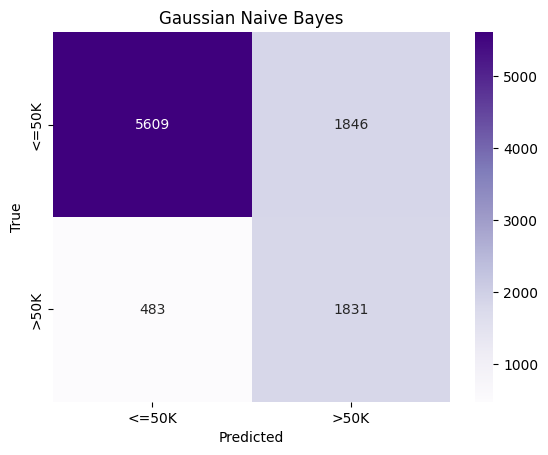

In [ ]:
# Visualize the confusion matrix for Bernoulli  Naive Bayes
cm = confusion_matrix(y_test, y_pred_BNB, labels = ['<=50K', '>50K'])
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Gaussian Naive Bayes')
plt.show()

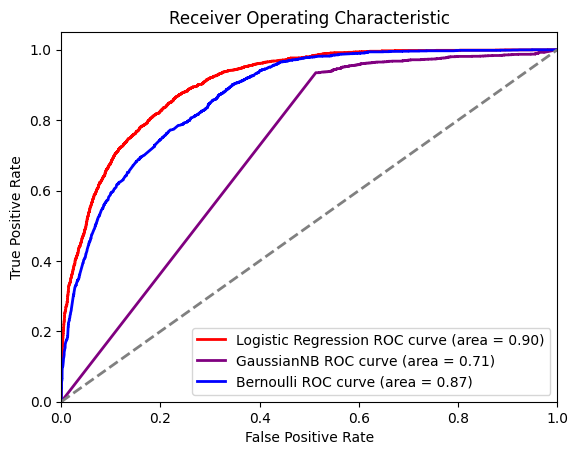

In [ ]:
# Plotting the ROC Curve
fpr_LOG, tpr_LOG, thresholds = roc_curve(y_test, y_probs_LOG, pos_label=">50K")
roc_auc_LOG = auc(fpr_LOG, tpr_LOG)

fpr_GNB, tpr_GNB, thresholds = roc_curve(y_test, y_probs_GNB, pos_label=">50K")
roc_auc_GNB = auc(fpr_GNB, tpr_GNB)

fpr_BNB, tpr_BNB, thresholds = roc_curve(y_test, y_probs_BNB, pos_label=">50K")
roc_auc_BNB = auc(fpr_BNB, tpr_BNB)

plt.figure()
plt.plot(fpr_LOG, tpr_LOG, color='red', lw=2, label=f'Logistic Regression ROC curve (area = {roc_auc_LOG:.2f})')
plt.plot(fpr_GNB, tpr_GNB, color='purple', lw=2, label=f'GaussianNB ROC curve (area = {roc_auc_GNB:.2f})')
plt.plot(fpr_BNB, tpr_BNB, color='blue', lw=2, label=f'Bernoulli ROC curve (area = {roc_auc_BNB:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

#**Step 4: Comparative Analysis**

**1.  Compare the performance of Logistic Regression vs. Naive Bayes on each dataset.**

Here also the Logistic Regression achieved higher scores across all metrics.
This may be because the features are both numerical and categorical, and Logistic Regression can handle any type of features. On the other hand, both naïve bayes models that I used (Gaussian, Bernoulli) handle specific type of feature, Bernoulli works with binary and Gaussian work withs continues.

**2. Discuss how dataset characteristics (feature types, distributions) influenced results**.

Naïve bayes models didn’t perform well. That because the features are numerical and categorical.

**3. Explore how preprocessing choices affected model performance.**

The most important prepossessing step in this dataset was encoding the categorical features, as the models can’t handle categorical data.

**4. Reflect on which model you would recommend for each dataset and why**.

Logistic Regression because it can handle any type of features.
